In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Ejercicio 1: Determinación del contenido de Clorofila foliar usando datos espectrales

Es posible determinar la cantidad de clorofila contenida en las hojas de las plantas usando un índice conocido como el Area Normalizada sobre la Curva de Reflectancia (NAOC, por sus siglas en inglés, Normalized Area Over Reflectance Curve). La curva de reflectancia es la reflectividad de una dada superficie a diferentes longitudes de onda y es característica de dicha superficie. Esta curva puede ser medida in situ con un radiómetro de campo o bien remotamente mediante sensores multiespectrales montados en satélites.

El NAOC se define como:

$NAOC = 1- \frac{\int_{a}^{b} \rho \,d\lambda}{\rho_{max} (b-a)}$ [1]

Donde: ρ es la reflectancia, λ es la longitud de onda, a y b son los límites de integración y ρmax es lareflectancia correspondiente a la longitud de onda b, tal como se muestra en la figura 1. La relación exacta entre el NAOC y la concentración foliar de clorofila (medida en µg/cm2) se determina finalmente con mediciones de campo de clorofila de la región de interés.

##### a) Explicar por qué la ecuación (1) representa el área normalizada sobre la curva de reflectancia.
Ayuda: usar las áreas sombreadas en turquesa y amarillo de la figura 1.

##### b) Los datos del archivo adjunto reflectancia.csv corresponden a la curva espectral (expresada en porcentaje de reflectividad en funci´on de la longitud de onda) medida en campo de un cultivo de maiz. Graficá la curva espectral y calculá el NAOC de este cultivo usando como límites de integración a = 643,71 nm y b = 795,4 nm.

In [16]:
# Read reflectancia.csv file with pandas
url_reflc = 'https://raw.githubusercontent.com/francobarrionuevoenv21/MAIE_devs_pub/main/MetodosNumericos/TPE1_Clorofila/datos/reflectividad.csv'
data_reflc = pd.read_csv(url_reflc, header = None)

# Display head dataset
data_reflc.head(5)

,0,1
0,450.03,1.2921
1,450.79,1.2609
2,451.55,1.3761
3,452.31,1.4257
4,453.07,1.5220


In [32]:
# Store data values as numpy arrays
lambda_data = data_reflc.loc[:, 0].values
rho_data = data_reflc.loc[:, 1].values

# Filter data accordint integration limits
lambda_a = 643.71
lambda_b = 795.4

lambda_data_f = lambda_data[(lambda_data >= lambda_a) & (lambda_data <= lambda_b)]
rho_data_f = rho_data[(lambda_data >= lambda_a) & (lambda_data <= lambda_b)]

**Gráfico de la firma espectral**

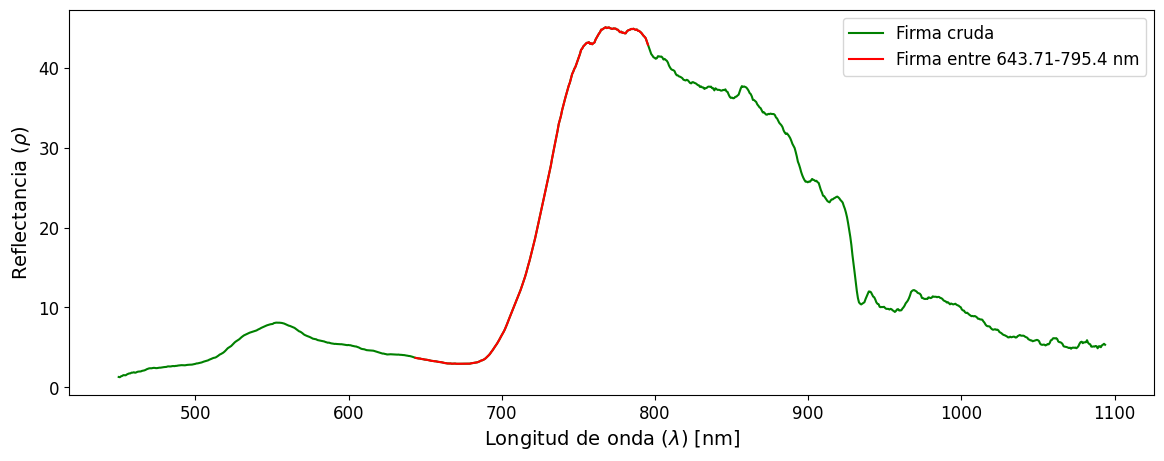

In [ ]:
# Plot data
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(lambda_data, rho_data, color = 'green', label = 'Firma cruda')
ax.plot(lambda_data_f, rho_data_f, color = 'red', label = f'Firma entre {lambda_a}-{lambda_b} nm')
ax.set_ylabel(r'Reflectancia ($\rho$)', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r'Longitud de onda ($\lambda$) [nm]', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=12)

**Cálculo del NAOC entre 643,71 y 795,4 nm**

In [69]:
# Solve integral
## Compute lambda deltas
delta_lambda = np.diff(lambda_data_f)

## Initialize integral solution (int_slt)
int_slt = 0

## Solve integral. For loop approach
for i in range(len(delta_lambda)):
    int_slt += delta_lambda[i]*rho_data_f[i+1] # Compute integral by its upper limit

# Solve rho_max * (b-a) (normalization term, norm_t)
norm_t = rho_data_f[-1]*(lambda_b-lambda_a)

# NAOC solution
naoc_ab = 1-(int_slt/norm_t)

# Print solution
print(f'Solución NAOC para la firma espectral entre {lambda_a} y {lambda_b} nm: {naoc_ab:.4f}')

Solución NAOC para la firma espectral entre 643.71 y 795.4 nm: 0.4857


## Ejercicio 2: Determinaci´on de la concentraci´on de Clorofila-a en el mar

El fitoplancton es el conjunto de organismos autótrofos unicelulares, microscroscópicos y flotantes que se encuentran en las capas superficiales iluminadas de los océanos, y constituye la base de la cadena alimentaria acuática. La presencia de fitoplancton en aguas oceánicas se pone en evidencia debido a que ocurre un cambio significativo en el color del mar, dado por la variación de la concentración de la concentraci´on de la clorofila-a (Cl-a), el pigmento fotosintético más abundante de su composición. Es por ello que la concentración de Cl-a es un buen indicador o proxy de la abundancia de fitoplancton en un
determinado lugar. La variación en la respuesta espectral del océano en el rango visible se puede detectar mediante sensores ópticos montados en plataformas satelitales, constituyendo la base del estudio del color del mar (ver, por ejemplo, la figura 2).

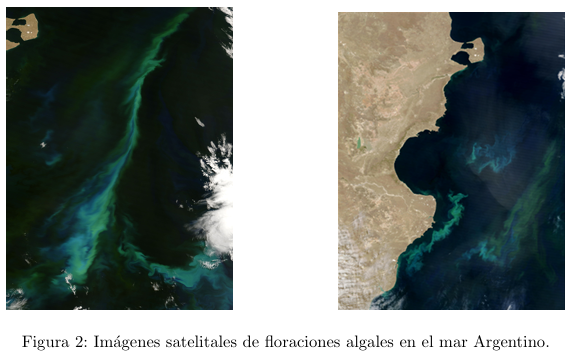

A partir de la regresión de mediciones conjuntas de concentración de Cl-a y la respuesta espectral del cuerpo de agua tomadas in situ, se han desarrollado algoritmos empíricos para determinar la concentración de Cl-a a partir de mediciones satelitales de la reflectancia emergente del océano ρw. Estos algoritmos se sustentan en el hecho de que un aumento de la Cl-a en el agua produce una disminución en la reflectancia de agua en el azul y un aumento de la misma en la región del verde de la parte visible del espectro electomagnético (ver figura 3). Teniendo esto en cuenta, los algoritmos empíricos se basan en relaciones de dichas bandas.

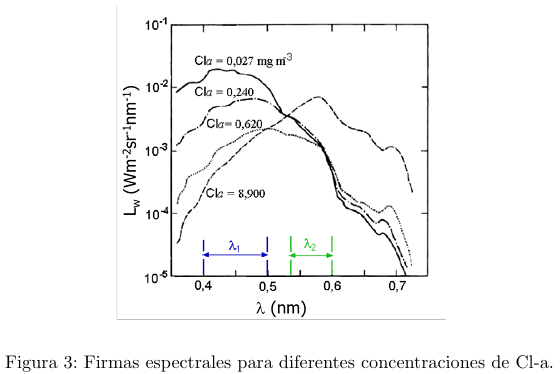

Los algoritmos estándares que usan diferentas misiones satelitales son empíricos (conocidos como OC#), y su forma funcional general es [2]:

$\log_{10}(Cla) = a_0 + \sum_{i=1}^{4} a_i \left( \log_{10} \left( \frac{\rho_w(\lambda_{\mathrm{blue}})}{\rho_w(\lambda_{\mathrm{green}})} \right) \right)^i$ [2]

donde Cl-a está en unidades de [mgm−3], λblue y λgreen corresponden a las mediciones en las bandas del azul y del verde del sensor en cuestión. Los coeficientes ai dependen también del sensor, y se encuentran especificados en tablas como la que se muestra en la tabla 1.

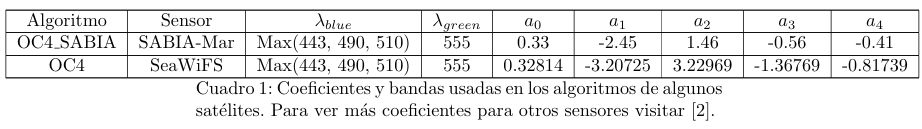

El archivo adjunto Firma.csv contiene los datos de una firma espectral, es decir un conjunto de datos del tipo (λ[nm], ρw). Estos datos in-situ fueron tomado con un espectro-radiómetro en el Golfo San Matías de las costas de Argentina, en febrero de 2013 (figura 4).

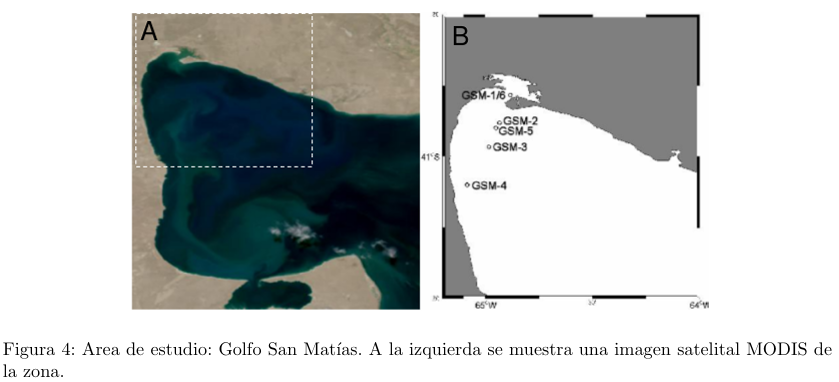

In [3]:
# Read firmas.csv file with pandas
url_firma = 'https://raw.githubusercontent.com/francobarrionuevoenv21/MAIE_devs_pub/refs/heads/main/MetodosNumericos/TPE1_Clorofila/datos/firma.csv'
data_firma = pd.read_csv(url_firma, header = None)

# Display head dataset
data_firma.head(5)

,0,1
0,350,0.012856
1,351,0.012842
2,352,0.012908
3,353,0.013129
4,354,0.013183


##### a) Graficá la firma espectral en la región del visible e infrarojo cercano.

In [4]:
# Store data values as numpy arrays
lambda_firma = data_firma.loc[:, 0].values
rho_firma = data_firma.loc[:, 1].values

# Define blue and green ranges limits (nm)
vis_min = 400
nir_max = 1200 

# Filter data accordint integration limits
lambda_firma_f = lambda_firma[(lambda_firma >= vis_min) & (lambda_firma <= nir_max)]
rho_firma_f = rho_firma[(lambda_firma >= vis_min) & (lambda_firma <= nir_max)]

**Gráfico firma espectral Vis-NIR**

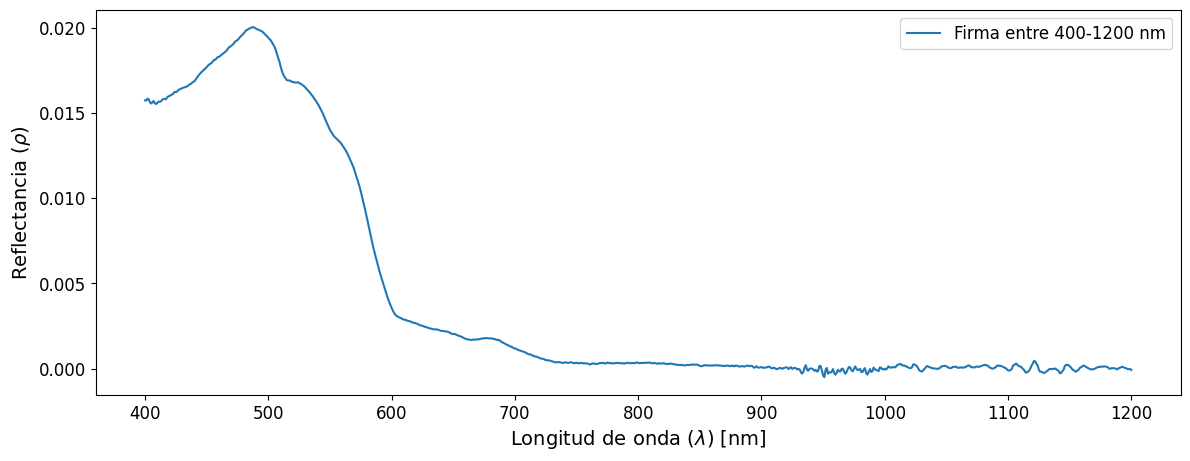

In [5]:
# Plot data
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(lambda_firma_f, rho_firma_f, label = f'Firma entre {vis_min}-{nir_max} nm')
ax.set_ylabel(r'Reflectancia ($\rho$)', fontsize = 14)
ax.tick_params(axis='y', labelsize=12) 
ax.set_xlabel(r'Longitud de onda ($\lambda$) [nm]', fontsize = 14)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=12)

##### b) Calculá cuánto mediría un sensor en sus bandas centradas en el azul: λazul1 = 443nm, λazul2 = 490nm, λazul3= 510nm; y en el verde: λverde = 555nm. Suponé que se trata de un sensor ideal que tiene un ancho de banda de 10nm en dichas bandas.

In [6]:
# Define mid lambda value (nm)
lambdab1 = 443
lambdab2 = 490
lambdab3 = 510
lambdag = 555

# Define delta lambda (nm)
deltal = 10

**Cómputo del valor medido como la media del valor central $\lambda_{i} \pm 10$ $nm$**

In [7]:
# Blue bands
lambdab1_meas = (rho_firma[(lambda_firma >= lambdab1-deltal) & (lambda_firma <= lambdab1+deltal)]).mean()
lambdab2_meas = (rho_firma[(lambda_firma >= lambdab2-deltal) & (lambda_firma <= lambdab2+deltal)]).mean()
lambdab3_meas = (rho_firma[(lambda_firma >= lambdab3-deltal) & (lambda_firma <= lambdab3+deltal)]).mean()

# Green band
lambdag_meas = (rho_firma[(lambda_firma >= lambdag-deltal) & (lambda_firma <= lambdag+deltal)]).mean()

# Print results
print(f'Valor rho(lambda_blue1):{lambdab1_meas:.4f}')
print(f'Valor rho(lambda_blue2):{lambdab2_meas:.4f}')
print(f'Valor rho(lambda_blue3):{lambdab3_meas:.4f}')
print(f'Valor rho(lambda_green):{lambdag_meas:.4f}')


Valor rho(lambda_blue1):0.0172
Valor rho(lambda_blue2):0.0198
Valor rho(lambda_blue3):0.0179
Valor rho(lambda_green):0.0136


##### C) Usando el resultado del punto anterior calculá la concentación de Cl-a usando el modelo de al menos uno de los dos sensores (OC4 SABIA u OC4). Para λazul us´a la longitud de onda cuyo valor de reflectancia sea el mayor de los tres calculados.

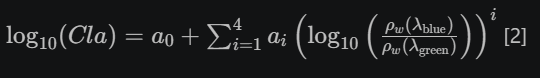

In [14]:
import math

# Define a function to solve the summation of a serie
def summ_ser(array_a, pw, lambab_max, lambdag):

    ## Sum intialization
    sum_res = 0

    for i in range(1, len(array_a)+1):
        log_arg = (pw*lambdab_max)/(pw*lambdag)
        sum_res += (array_a[i]*(math.log10(log_arg))**i)

    return suma_res

# -
def comp_cla(a0, array_a, pw, lambab_max, lambdag):
    return 10**(a0+summ_ser(array_a, pw, lambab_max, lambdag))

# -
#


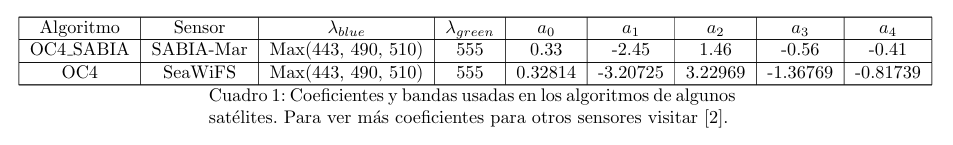

In [ ]:
# Transcript sensors parameters values and store it
a0_sab = 0.33
a0_oc4 = 0.32814

array_a_sab = np.array([-2.45, 1.46, -0.56, -0.41])
array_a_oc4 = np.array([-3.20725, 3.22969, -1.36769, -0.81739])

rhob_max = max(np.array([lambdab1_meas, lambdab2_meas, lambdab3_meas]))
rhog = lambdag_meas

In [ ]:
comp_cla(a0_sab, array_a_sab, pw, lambab_max, lambdag)

In [11]:
lambda_b

np.float64(0.01980661904761904)